<a href="https://colab.research.google.com/github/PerdomoVergaraFernando/Procesos-Estocasticos/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de la matriz de transición P

## Enunciado

Dada la matriz de transición \( P \) (de estados a, b, c, d, e, f, g):

$
P = \begin{pmatrix}
\frac{1}{4} & 0   & 0   & 0   & 0   & 0   & \frac{3}{4} \\
\frac18 & \frac18 & \frac14 & 0   & \frac14 & \frac18 & \frac{1}{8} \\
0   & 0   & \frac25 & \frac15 & \frac25 & 0   & 0   \\
0   & 0   & \frac12 & \frac12 & 0   & 0   & 0   \\
0   & 0   & 0   & \frac12 & \frac12 & 0   & 0   \\
0   & \frac15 & 0   & \frac15 & \frac15 & \frac15 & \frac15 \\
\frac45 & 0   & 0   & 0   & 0   & 0   & \frac15
\end{pmatrix}
$

Se requiere:

1. Escribir la matriz  $P$ y dibujar su diagrama de transiciones.
2. Determinar si la matriz tiene distribución límite (única).
3. Obtener la descomposición canónica, el límite de $ P^n $ y comparar con las distribuciones límite de las submatrices recurrentes.
4. Escribir un programa que encuentre la descomposición canónica de una matriz dada.


In [10]:
# 1. Importación de librerías necesarias

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.linalg import solve, block_diag

In [11]:
# 2. Definición de la matriz P
Estados  = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])
print("Matriz P:")
print(P)

Matriz P:
[[0.25  0.    0.    0.    0.    0.    0.75 ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]
 [0.8   0.    0.    0.    0.    0.    0.2  ]]


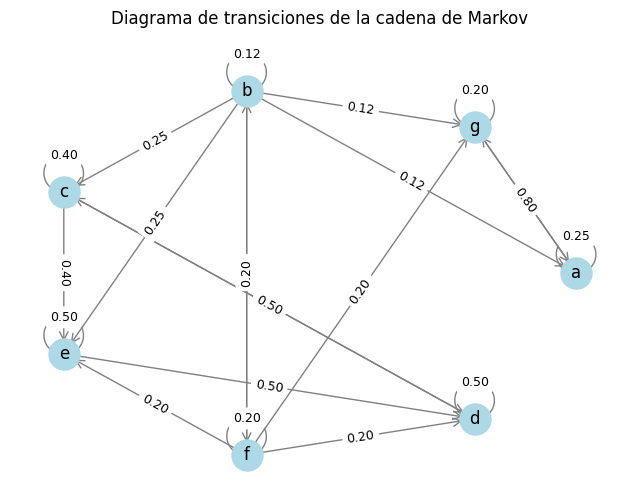

In [12]:
# 3. Diagrama de transiciones
G = nx.DiGraph()
for i, s_i in enumerate(Estados):
    for j, s_j in enumerate(Estados):
        prob = P[i, j]
        if prob > 0:
            G.add_edge(s_i, s_j, weight=prob)

pos = nx.circular_layout(G)
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray')
edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
plt.title("Diagrama de transiciones de la cadena de Markov")
plt.axis('off')
plt.show()

Distribución Límite

Para determinar si existe una distribución límite, hay que ver si la cadena de Markov alcanza un comportamiento estable al calcular potencias altas de la matriz de transición P. En este caso, no hay una única distribución límite que sirva para todos los estados, porque el sistema tiene más de una clase cerrada. Por lo tanto, el estado hacia el que evoluciona la cadena depende del punto de partida.

In [13]:
# Elevamos la matriz a una potencia grande
Pn = np.linalg.matrix_power(P, 20)

print("Matriz P elevada a la potencia 20:")
print(np.round(Pn, 4))

Matriz P elevada a la potencia 20:
[[0.5161 0.     0.     0.     0.     0.     0.4839]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.     0.     0.3333 0.4    0.2667 0.     0.    ]
 [0.172  0.     0.2222 0.2667 0.1778 0.     0.1613]
 [0.5161 0.     0.     0.     0.     0.     0.4839]]


#Clases de comunicación y periodicidad

· Clase recurrente R_1 = \{a, g\} (aperiódica por autolazos)

· Clase recurrente R_2 = \{c, d, e\} (aperiódica por autolazo en c)

· Clase transitoria T = \{b, f\} (aperiódica)

No hay distribución límite única porque la cadena no es irreducible.

#Orden canónico

Reordenamos los estados como [b, f, a, g, c, d, e].

In [14]:
#Matriz Canonica
B = np.array([
    [1/8, 1/8,   1/8,   1/8,   1/4,   0,   1/4],
    [1/5, 1/5,     0,   1/5,     0, 1/5,   1/5],
    [  0,   0,   1/4,   3/4,     0,   0,     0],
    [  0,   0,   4/5,   1/5,     0,   0,     0],
    [  0,   0,     0,     0,   2/5, 1/5,   2/5],
    [  0,   0,     0,     0,   1/2, 1/2,     0],
    [  0,   0,     0,     0,   0,   1/2,   1/2]
])
print("Matriz B:")
print(B)

Matriz B:
[[0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
 [0.2   0.2   0.    0.2   0.    0.2   0.2  ]
 [0.    0.    0.25  0.75  0.    0.    0.   ]
 [0.    0.    0.8   0.2   0.    0.    0.   ]
 [0.    0.    0.    0.    0.4   0.2   0.4  ]
 [0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5  ]]


Las submatrices:

Q (transitorio → transitorio):
  Q = \begin{pmatrix} \frac18 & \frac18 \\ \frac15 & \frac15 \end{pmatrix}

R (transitorio → recurrente):
  R = \begin{pmatrix}
   \frac18 & \frac18 & \frac14 & 0   & \frac14 \\
   0   & \frac15 & 0   & \frac15 & \frac15
   \end{pmatrix}

$S_1$ (recurrente $R_1$):
  $S_1 = \begin{pmatrix} 1/4 & 3/4 \\ 4/5 & 1/5 \end{pmatrix}$

$S_2$ (recurrente $R_2$):
  $S_2 = \begin{pmatrix}
   \frac25 & \frac15 & \frac25 \\
   \frac12 & \frac12 & 0   \\
   0   & \frac12 & \frac12
   \end{pmatrix}$

 Distribuciones estacionarias de las submatrices recurrentes

$\pi_1$ para $R_1:
  \pi_1 = \left( \frac{16}{31}, \frac{15}{31} \right) $

$\pi_2$ para $R_2$:
$\pi_2 = \left( \frac{1}{3}, \frac{2}{5}, \frac{4}{15} \right) $

Matriz fundamental N y absorción B

N = $(I - Q)^{-1}$ = \begin{pmatrix}
\frac{32}{27} & \frac5{27} \\
\frac8{27} & \frac{35}{27}
\end{pmatrix}

B = N R = \begin{pmatrix}
\frac4{27} & \frac5{27} & \frac8{27} & \frac1{27} & \frac13 \\
\frac1{27} & \frac8{27} & \frac2{27} & \frac7{27} & \frac13
\end{pmatrix}

Probabilidades de absorción por clase:

Desde cualquier transitorio (b o f):
    Clase $R_1$: $\frac13$,   Clase $R_2$: $\frac23$

Límite de P^n en el orden canónico

L = $\lim_{n\to\infty} P_{\text{can}}^n =
\begin{pmatrix}
0 & 0 & \frac{16}{93} & \frac{15}{93} & \frac{2}{9} & \frac{4}{15} & \frac{8}{45} \\[4pt]
0 & 0 & \frac{16}{93} & \frac{15}{93} & \frac{2}{9} & \frac{4}{15} & \frac{8}{45} \\[4pt]
0 & 0 & \frac{16}{31} & \frac{15}{31} & 0 & 0 & 0 \\[4pt]
0 & 0 & \frac{16}{31} & \frac{15}{31} & 0 & 0 & 0 \\[4pt]
0 & 0 & 0 & 0 & \frac{1}{3} & \frac{2}{5} & \frac{4}{15} \\[4pt]
0 & 0 & 0 & 0 & \frac{1}{3} & \frac{2}{5} & \frac{4}{15} \\[4pt]
0 & 0 & 0 & 0 & \frac{1}{3} & \frac{2}{5} & \frac{4}{15}
\end{pmatrix}$

Interpretación:

Las dos primeras filas (transitorios) convergen a la misma distribución:

$\frac{1}{3}$ $\pi_1$ sobre $\{a,g\}$ y $\frac{2}{3}\pi_2$ sobre $\{c,d,e\}.$

Las filas de $R_1$ convergen a $\pi_1$ sobre sí mismas.

Las filas de $R_2$ convergen a $\pi_2$ sobre sí mismas.

 Comparación con las distribuciones límite de las submatrices

El bloque recurrente $S_1$ tiene límite $S_1^\infty$ = \begin{pmatrix} \pi_1 \\ \pi_1 \end{pmatrix}, que coincide con el bloque (3‑4, 3‑4) de L.

El bloque recurrente $S_2$ tiene límite $S_2^\infty$ = \begin{pmatrix} \pi_2 \\ \pi_2 \\ \pi_2 \end{pmatrix}, que coincide con el bloque (5‑7, 5‑7) de L.

Desde estados transitorios, la distribución límite es la mezcla ponderada de $\pi_1$ y $\pi_2$ (con pesos $\frac13$ y $\frac23$).

#Programa que encuentra la descomposición canónica de una matriz

In [15]:
import numpy as np
from IPython.display import display, Math
from sympy import Matrix, latex

# Agregar flechas donde la probabilidad sea mayor que cero
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        if P[i, j] != 0:
            G.add_edge(Estados[i], Estados[j])

# Encontrar clases de comunicación
clases = list(nx.strongly_connected_components(G))

cerradas = []
transitorias = []

# Revisar si cada clase es cerrada
for clase in clases:
    es_cerrada = True

    for estado in clase:
        for vecino in G.successors(estado):
            if vecino not in clase:
                es_cerrada = False
                break
        if not es_cerrada:
            break

    if es_cerrada:
        cerradas.append(sorted(list(clase)))
    else:
        transitorias.extend(sorted(list(clase)))

# Nuevo orden: primero transitorios y luego clases cerradas
nuevo_orden = transitorias.copy()

for clase in cerradas:
    nuevo_orden.extend(clase)

# Obtener índices del nuevo orden
indices = [Estados.index(e) for e in nuevo_orden]

# Matriz canónica.
P_canonica = P[np.ix_(indices, indices)]

# Mostrar resultados
print("Estados Transitorios:", transitorias)
print("Clases Recurrentes:", cerradas)
print("Nuevo orden:", nuevo_orden)


P_canonica_sympy = Matrix(P_canonica)
display(Math(r"P_{\text{canónica}}=" + latex(P_canonica_sympy)))

Estados Transitorios: ['b', 'f']
Clases Recurrentes: [['a', 'g'], ['c', 'd', 'e']]
Nuevo orden: ['b', 'f', 'a', 'g', 'c', 'd', 'e']


<IPython.core.display.Math object>